## Data Preprocessing Experiment

주어진 데이터에 대해 다양한 전처리를 시도하고, 가장 적절한 전처리 방식을 채택

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix, accuracy_score, roc_auc_score
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras import optimizers
import tensorflow as tf
from tensorflow.keras import backend as k
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Dropout, Dense

/Users/wheemin/Desktop/my_project/KAMP_AI제조데이터분석/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### 0.EDA

In [2]:
labeled_cn7 = pd.read_csv('../data/1. 사출성형기 AI 데이터셋/moldset_labeled_cn7.csv', index_col=0)
labeled_rg3 = pd.read_csv('../data/1. 사출성형기 AI 데이터셋/moldset_labeled_rg3.csv', index_col=0)
unlabeled_cn7 = pd.read_csv('../data/1. 사출성형기 AI 데이터셋/moldset_unlabeled_cn7.csv', index_col=0)
unlabeled_rg3 = pd.read_csv('../data/1. 사출성형기 AI 데이터셋/moldset_unlabeled_rg3.csv', index_col=0)

In [63]:
# 클래스 있는 데이터, 없는 데이터를 모두 불러온 후 학습 데이터셋 지정
class DataLoader_cn7():
    def __init__(self):
        # 클래스 변수가 존재하는 데이터를 불러옴
        labeled_cn7 = pd.read_csv('../data/1. 사출성형기 AI 데이터셋/moldset_labeled_cn7.csv', index_col=0)

        # 클래스 변수가 존재하지 않는 데이터를 불러옴
        unlabeled_cn7 = pd.read_csv('../data/1. 사출성형기 AI 데이터셋/moldset_unlabeled_cn7.csv', index_col=0)

        # train/test 데이터 분리
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
        for train_index, test_index in sss.split(labeled_cn7.loc[:,labeled_cn7.columns!='PassOrFail'], labeled_cn7['PassOrFail']):
            labeled_train_X = labeled_cn7.loc[:,labeled_cn7.columns!='PassOrFail'].iloc[train_index]
            labeled_test_X = labeled_cn7.loc[:,labeled_cn7.columns!='PassOrFail'].iloc[test_index]
            labeled_train_Y = labeled_cn7['PassOrFail'].iloc[train_index]
            labeled_test_Y = labeled_cn7['PassOrFail'].iloc[test_index]

        # train data
        self.labeled_train_X = labeled_train_X
        self.labeled_train_Y = labeled_train_Y
        # test data
        self.labeled_test_X = labeled_test_X
        self.labeled_test_Y = labeled_test_Y
        # data without target variable
        self.unlabeled = unlabeled_cn7

class DataLoader_rg3():
    def __init__(self):
        # 클래스 변수가 존재하는 데이터를 불러옴
        labeled_rg3 = pd.read_csv('../data/1. 사출성형기 AI 데이터셋/moldset_labeled_rg3.csv', index_col=0)

        # 클래스 변수가 존재하지 않는 데이터를 불러옴
        unlabeled_rg3 = pd.read_csv('../data/1. 사출성형기 AI 데이터셋/moldset_unlabeled_rg3.csv', index_col=0)

        # train/test 데이터 분리
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
        for train_index, test_index in sss.split(labeled_rg3.loc[:,labeled_rg3.columns!='PassOrFail'], labeled_rg3['PassOrFail']):
            labeled_train_X = labeled_rg3.loc[:,labeled_rg3.columns!='PassOrFail'].iloc[train_index]
            labeled_test_X = labeled_rg3.loc[:,labeled_rg3.columns!='PassOrFail'].iloc[test_index]
            labeled_train_Y = labeled_rg3['PassOrFail'].iloc[train_index]
            labeled_test_Y = labeled_rg3['PassOrFail'].iloc[test_index]

        # train data
        self.labeled_train_X = labeled_train_X
        self.labeled_train_Y = labeled_train_Y
        # test data
        self.labeled_test_X = labeled_test_X
        self.labeled_test_Y = labeled_test_Y
        # data without target variable
        self.unlabeled = unlabeled_rg3

structure of dataset (Data Leakage 주의⚠️)

```
원본 labeled data
     ↓
train/test split
     ↓
┌───────────────┐
│ Train         │
│ + Unlabeled   │.  ⭐️preprocessing, scaling 대상
└───────┬───────┘
        ↓
   scaler.fit()
        ↓
 transform
        ↓
Test → transform만
```

In [64]:
data_cn7 = DataLoader_cn7()
X_test_cn7 = data_cn7.labeled_test_X
y_test_cn7 = data_cn7.labeled_test_Y
X_with_label_cn7 = data_cn7.labeled_train_X
y_with_label_cn7 = data_cn7.labeled_train_Y
unlabeled_cn7 = data_cn7.unlabeled

data_rg3 = DataLoader_rg3()
X_test_rg3 = data_rg3.labeled_test_X
y_test_rg3 = data_rg3.labeled_test_Y
X_with_label_rg3 = data_rg3.labeled_train_X
y_with_label_rg3 = data_rg3.labeled_train_Y
unlabeled_rg3 = data_rg3.unlabeled

In [66]:
# check information for labeled data
# No missing values in labeled data
display(X_with_label_cn7.info())
print('number of missing values for CN7 data:',labeled_cn7.isna().sum().sum())
print()
display(X_with_label_rg3.info())
print('number of missing values for RG3 data:',labeled_rg3.isna().sum().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 847 entries, 51 to 876
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Injection_Time            847 non-null    float64
 1   Filling_Time              847 non-null    float64
 2   Plasticizing_Time         847 non-null    float64
 3   Cycle_Time                847 non-null    float64
 4   Clamp_Close_Time          847 non-null    float64
 5   Cushion_Position          847 non-null    float64
 6   Plasticizing_Position     847 non-null    float64
 7   Clamp_Open_Position       847 non-null    float64
 8   Max_Injection_Speed       847 non-null    float64
 9   Max_Screw_RPM             847 non-null    float64
 10  Average_Screw_RPM         847 non-null    float64
 11  Max_Injection_Pressure    847 non-null    float64
 12  Max_Switch_Over_Pressure  847 non-null    float64
 13  Max_Back_Pressure         847 non-null    float64
 14  Average_Back_P

None

number of missing values for CN7 data: 0

<class 'pandas.core.frame.DataFrame'>
Index: 827 entries, 1240 to 1597
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Injection_Time            827 non-null    float64
 1   Filling_Time              827 non-null    float64
 2   Plasticizing_Time         827 non-null    float64
 3   Cycle_Time                827 non-null    float64
 4   Clamp_Close_Time          827 non-null    float64
 5   Cushion_Position          827 non-null    float64
 6   Plasticizing_Position     827 non-null    float64
 7   Clamp_Open_Position       827 non-null    float64
 8   Max_Injection_Speed       827 non-null    float64
 9   Max_Screw_RPM             827 non-null    float64
 10  Average_Screw_RPM         827 non-null    float64
 11  Max_Injection_Pressure    827 non-null    float64
 12  Max_Switch_Over_Pressure  827 non-null    float64
 13  Max_Back_Pressure       

None

number of missing values for RG3 data: 0


In [67]:
# check information for unlabeled data
# No missing values in unlabeled data
display(unlabeled_cn7.info())
print('number of missing values for CN7 data(unlabeled):',unlabeled_cn7.isna().sum().sum())
print()
display(unlabeled_rg3.info())
print('number of missing values for RG3 data(unlabeled):',unlabeled_rg3.isna().sum().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 35239 entries, 114610 to 777220
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Injection_Time            35239 non-null  float64
 1   Filling_Time              35239 non-null  float64
 2   Plasticizing_Time         35239 non-null  float64
 3   Cycle_Time                35239 non-null  float64
 4   Clamp_Close_Time          35239 non-null  float64
 5   Cushion_Position          35239 non-null  float64
 6   Plasticizing_Position     35239 non-null  float64
 7   Clamp_Open_Position       35239 non-null  float64
 8   Max_Injection_Speed       35239 non-null  float64
 9   Max_Screw_RPM             35239 non-null  float64
 10  Average_Screw_RPM         35239 non-null  float64
 11  Max_Injection_Pressure    35239 non-null  float64
 12  Max_Switch_Over_Pressure  35239 non-null  float64
 13  Max_Back_Pressure         35239 non-null  float64
 14  Avera

None

number of missing values for CN7 data(unlabeled): 0

<class 'pandas.core.frame.DataFrame'>
Index: 35941 entries, 119515 to 795309
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Injection_Time            35941 non-null  float64
 1   Filling_Time              35941 non-null  float64
 2   Plasticizing_Time         35941 non-null  float64
 3   Cycle_Time                35941 non-null  float64
 4   Clamp_Close_Time          35941 non-null  float64
 5   Cushion_Position          35941 non-null  float64
 6   Plasticizing_Position     35941 non-null  float64
 7   Clamp_Open_Position       35941 non-null  float64
 8   Max_Injection_Speed       35941 non-null  float64
 9   Max_Screw_RPM             35941 non-null  float64
 10  Average_Screw_RPM         35941 non-null  float64
 11  Max_Injection_Pressure    35941 non-null  float64
 12  Max_Switch_Over_Pressure  35941 non-null  float64
 13  Max_Bac

None

number of missing values for RG3 data(unlabeled): 0


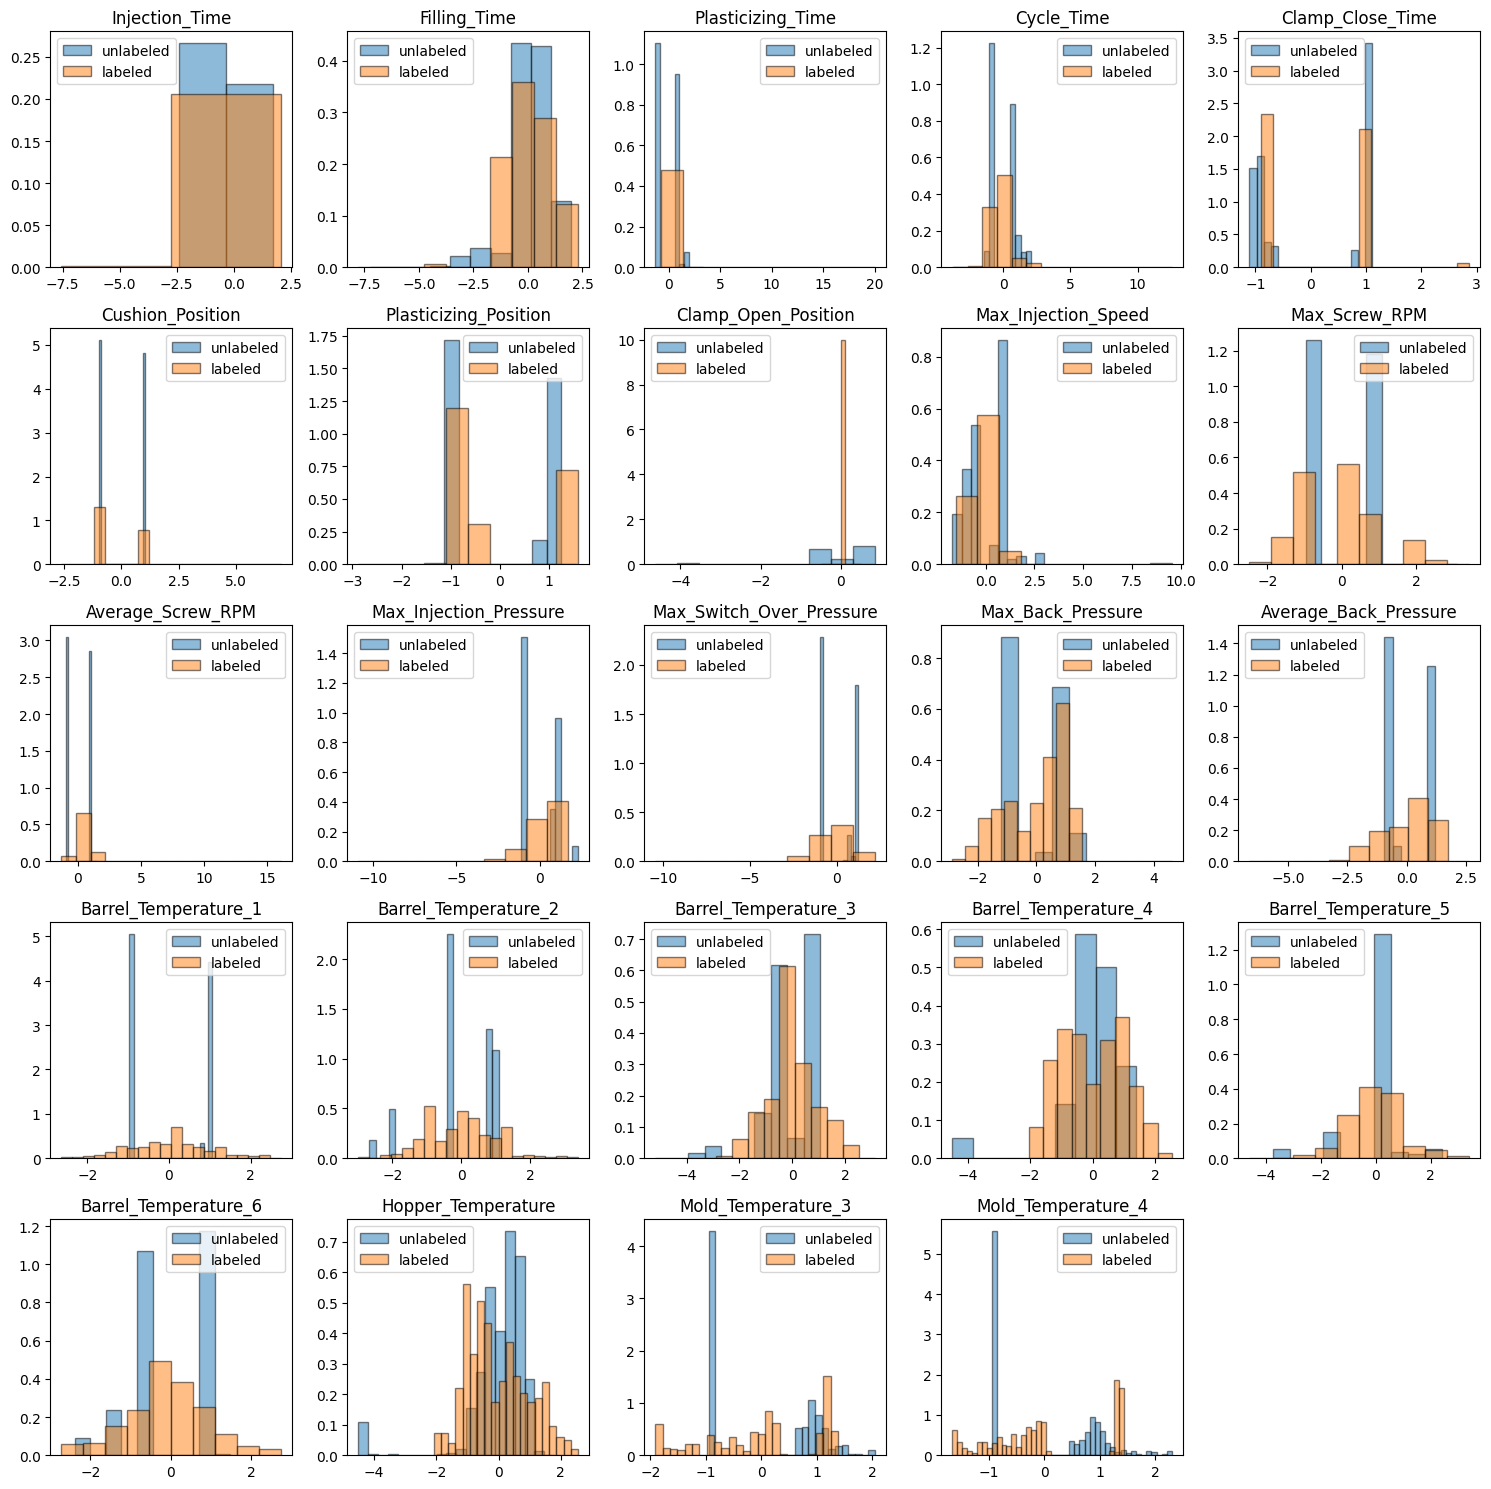

In [68]:
# visualize the distribution of every feature for each products
plt.figure(figsize=(15, 15))

bin = [2,10,10,15,17,20,10,10,10,10,15,10,10,10,10,20,20,10,10,10,10,20,25,35,35]

for index, value in enumerate(unlabeled_cn7.columns):
    ax = plt.subplot(5, 5, index + 1)
    ax.hist(x=unlabeled_cn7[value], bins=bin[index], alpha=0.5, edgecolor='black', label='unlabeled', density=True)
    ax.hist(x=X_with_label_cn7[value], bins=bin[index], alpha=0.5, edgecolor='black', label='labeled', density=True)
    plt.title(value)
    plt.legend()

plt.tight_layout()

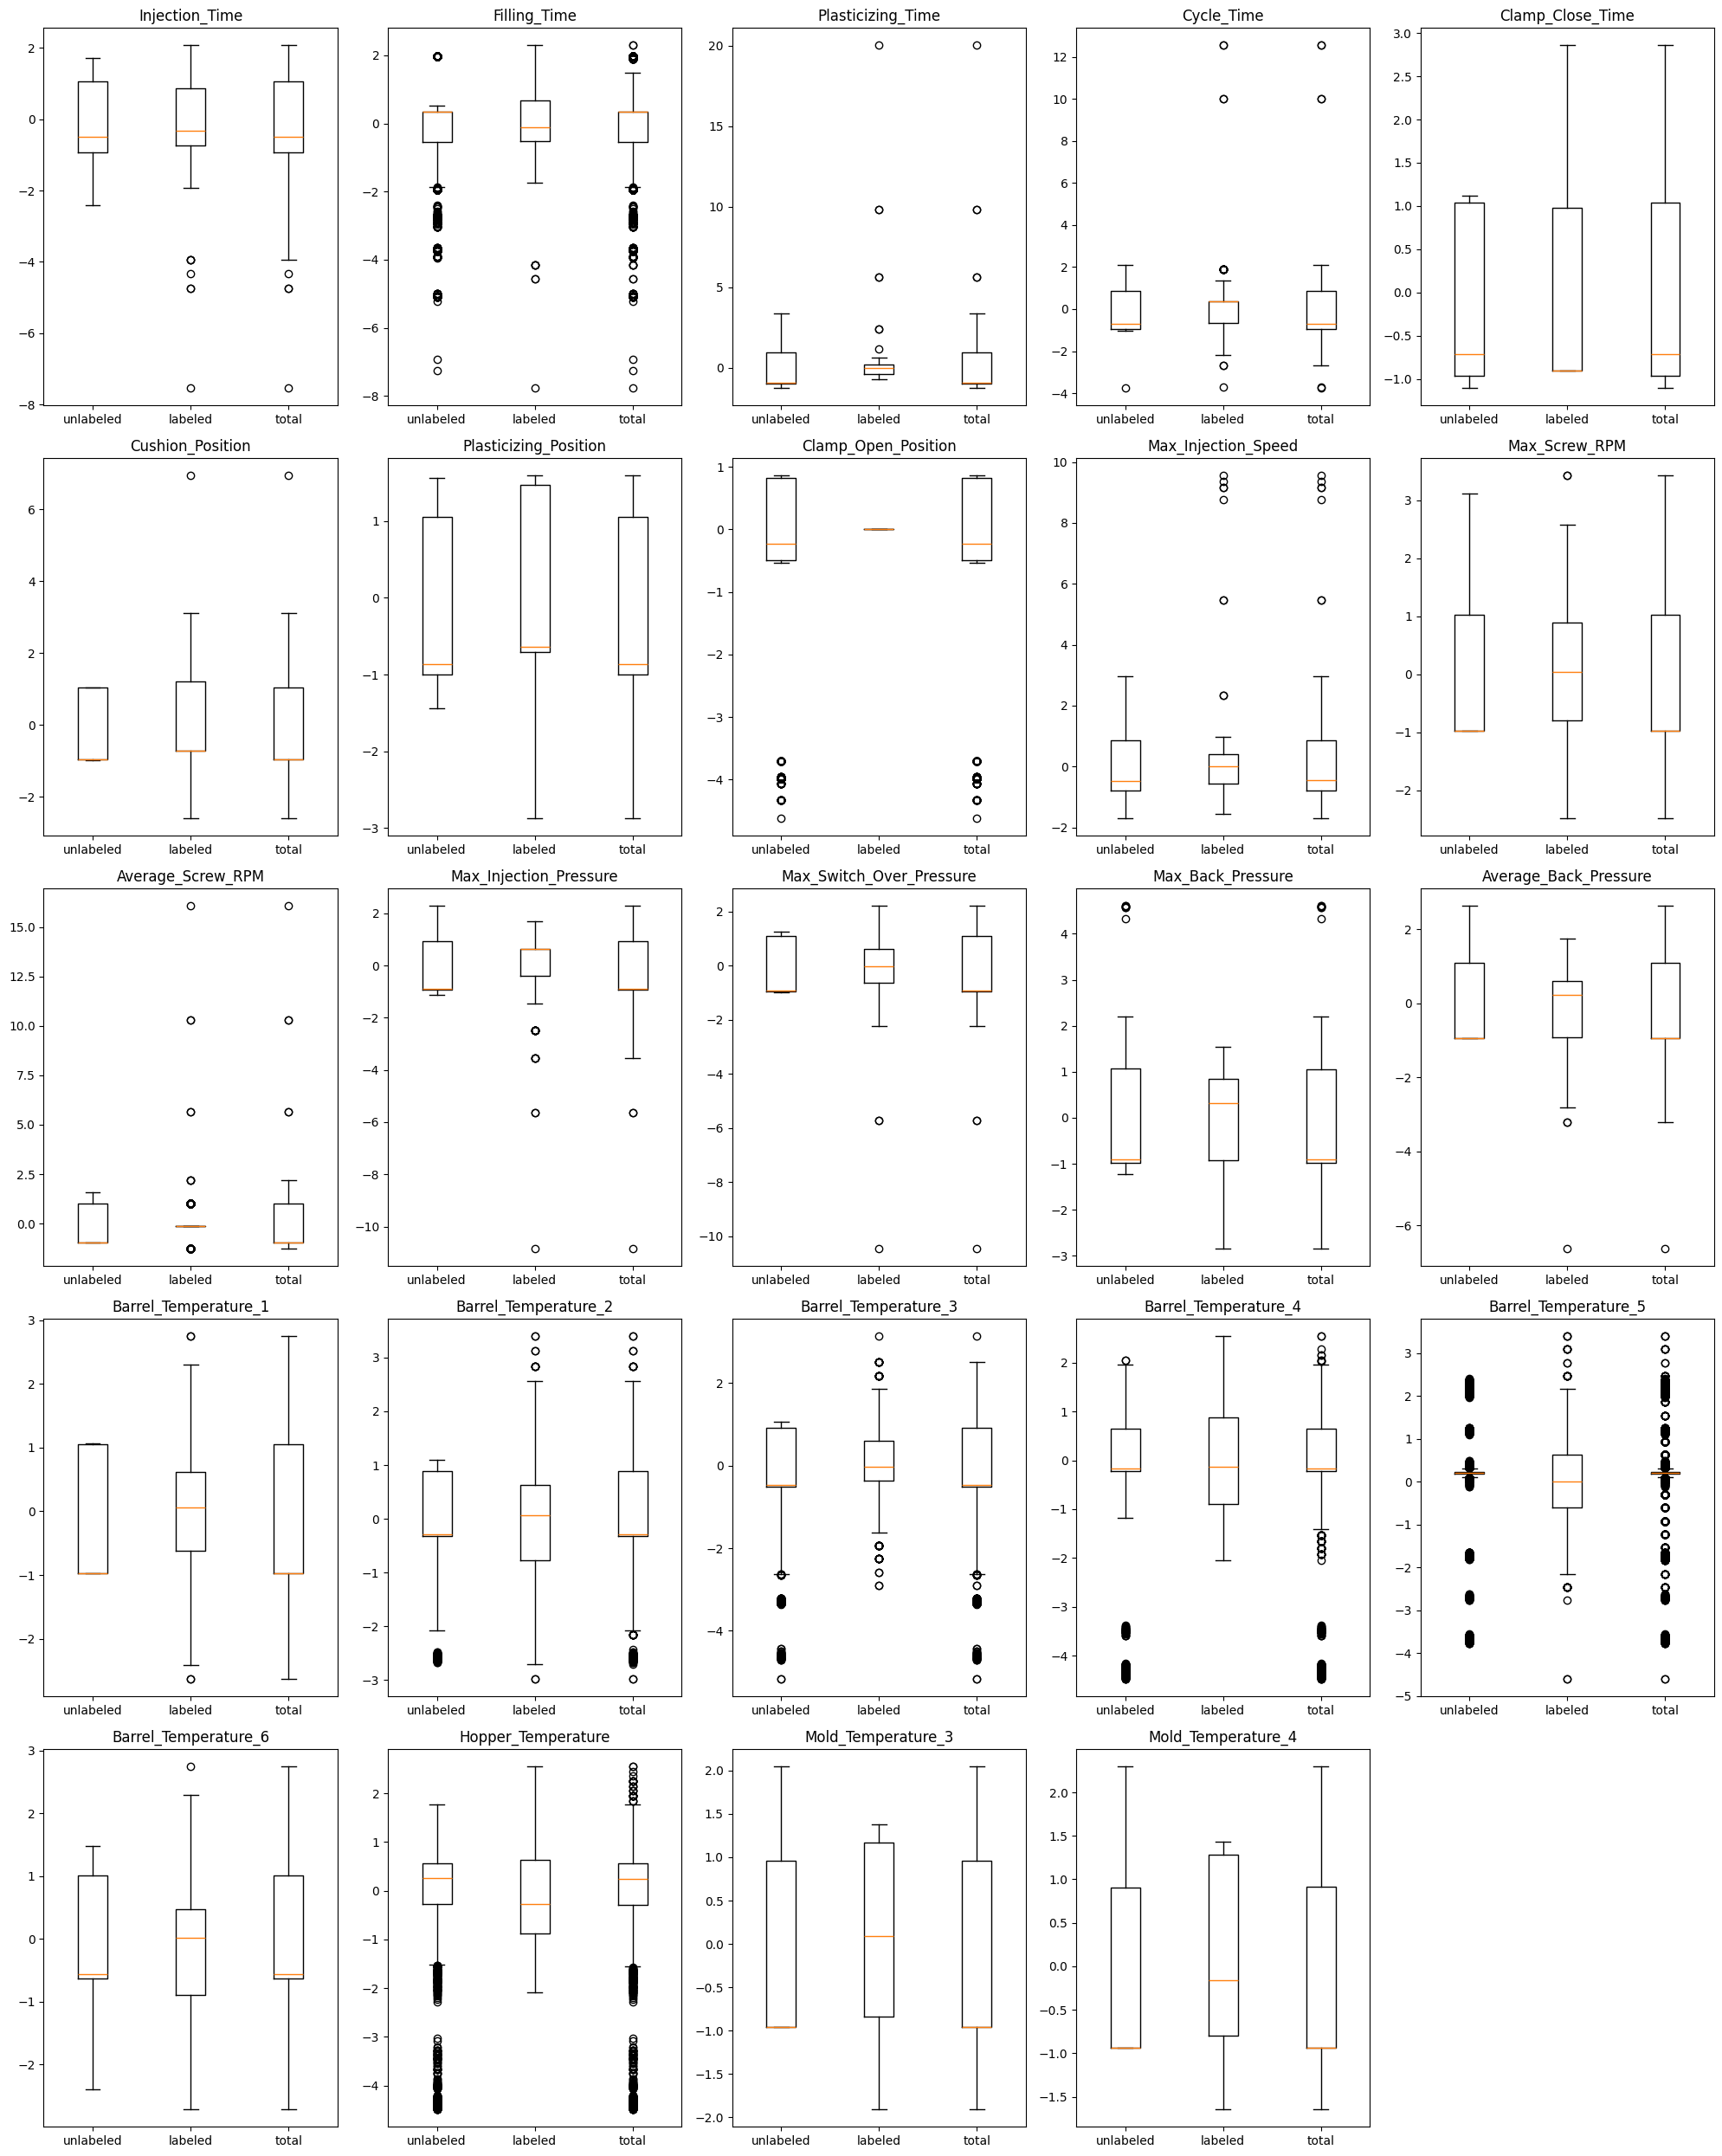

In [69]:
# draw boxplot
total_cn7 = pd.concat([unlabeled_cn7, X_with_label_cn7])
plt.figure(figsize=(20, 25))

for index, value in enumerate(unlabeled_cn7.columns):
    ax = plt.subplot(5, 5, index + 1)
    ax.boxplot(x=[unlabeled_cn7[value],X_with_label_cn7[value],total_cn7[value]], tick_labels=['unlabeled','labeled','total'])
    ax.set_title(value)

plt.tight_layout()

[CN7]
- `labeled` : Clamp_Open_Position이 모두 0
- `unlabeled`: Barrel_Temperature_4, Hopper_Temperature -4 부근의 값 이상치로 보임

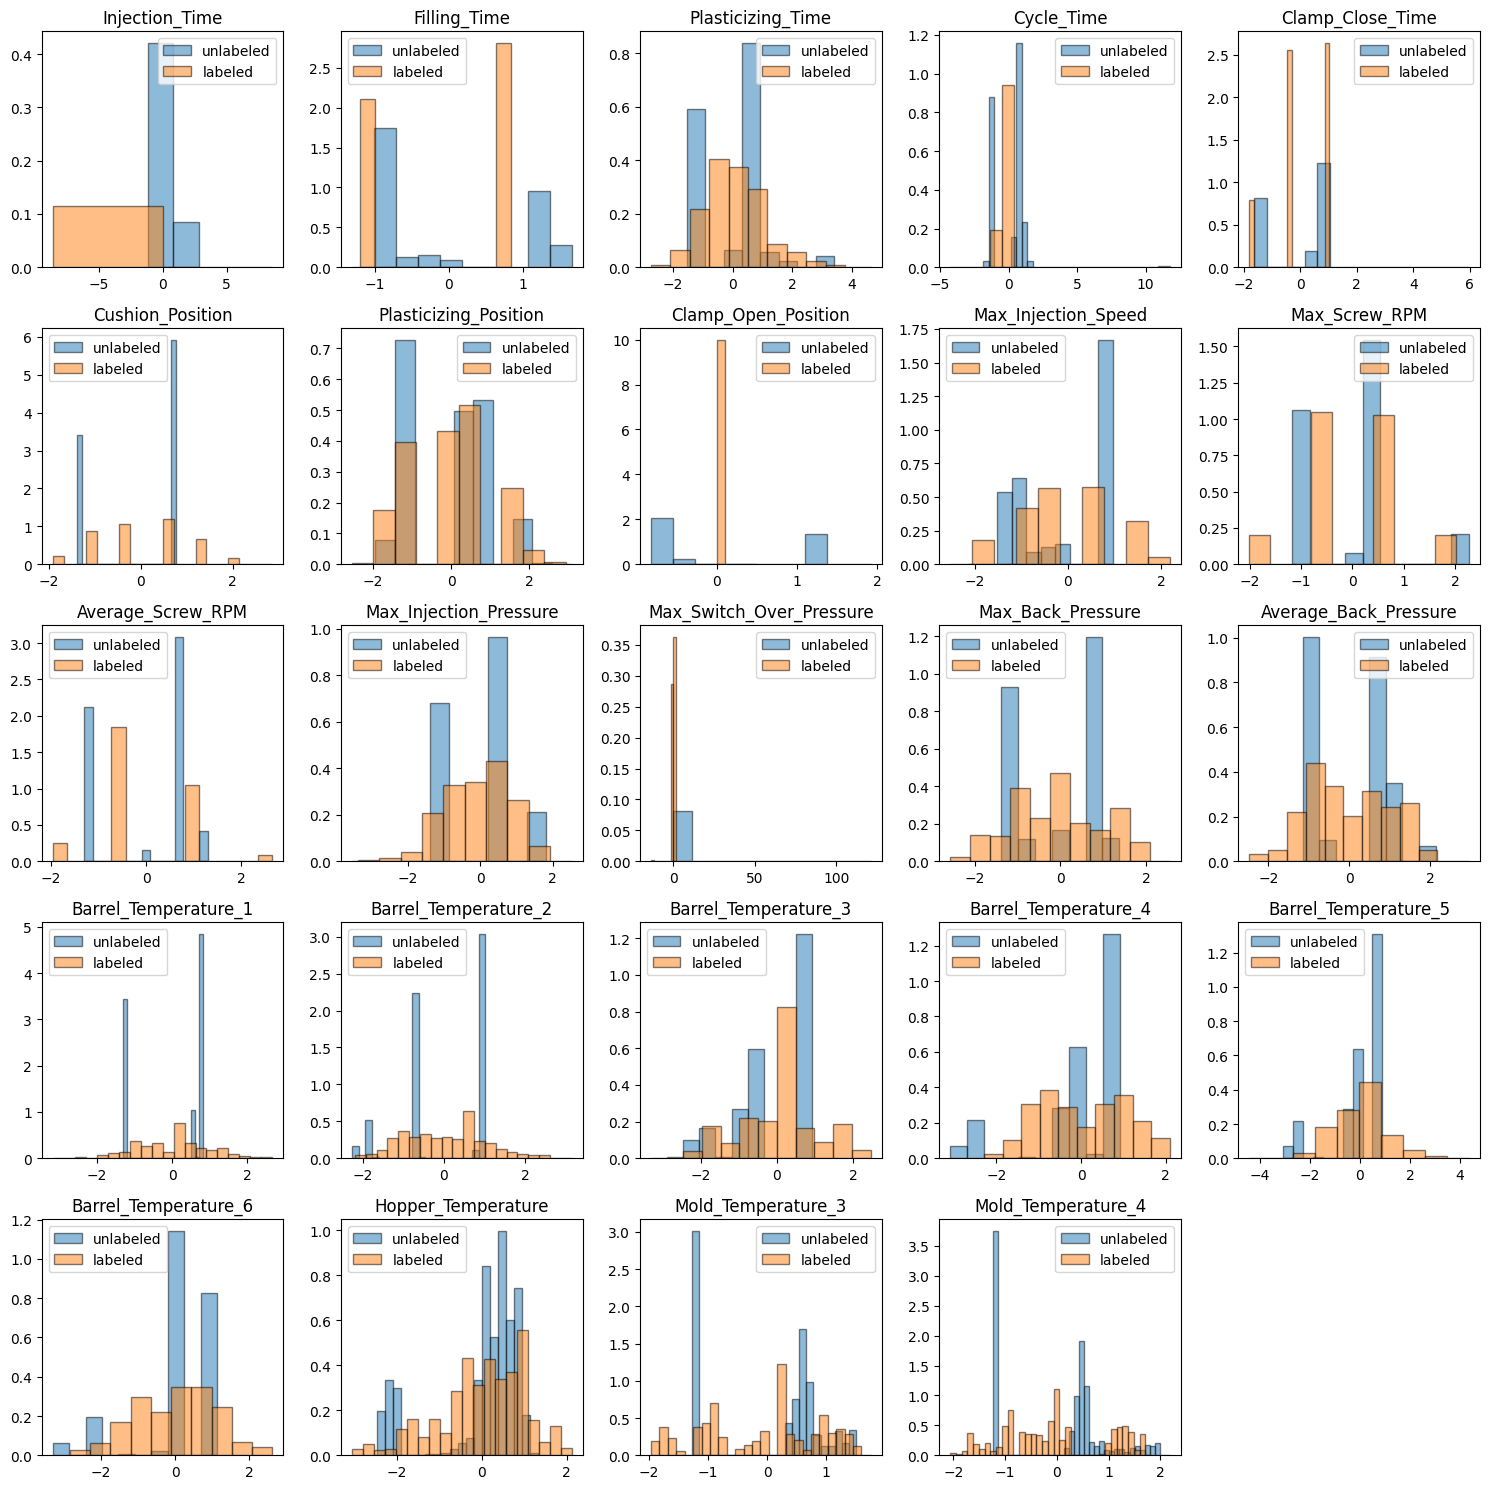

In [70]:
# visualize the distribution of every feature for each products
# Product : RG3
plt.figure(figsize=(15, 15))

bin = [2,10,10,15,17,20,10,10,10,10,15,10,10,10,10,20,20,10,10,10,10,20,25,35,35]

for index, value in enumerate(unlabeled_rg3.columns):
    ax = plt.subplot(5, 5, index + 1)
    ax.hist(x=unlabeled_rg3[value], bins=bin[index], alpha=0.5, edgecolor='black', label='unlabeled', density=True)
    ax.hist(x=X_with_label_rg3[value], bins=bin[index], alpha=0.5, edgecolor='black', label='labeled', density=True)
    plt.title(value)
    plt.legend()

plt.tight_layout()

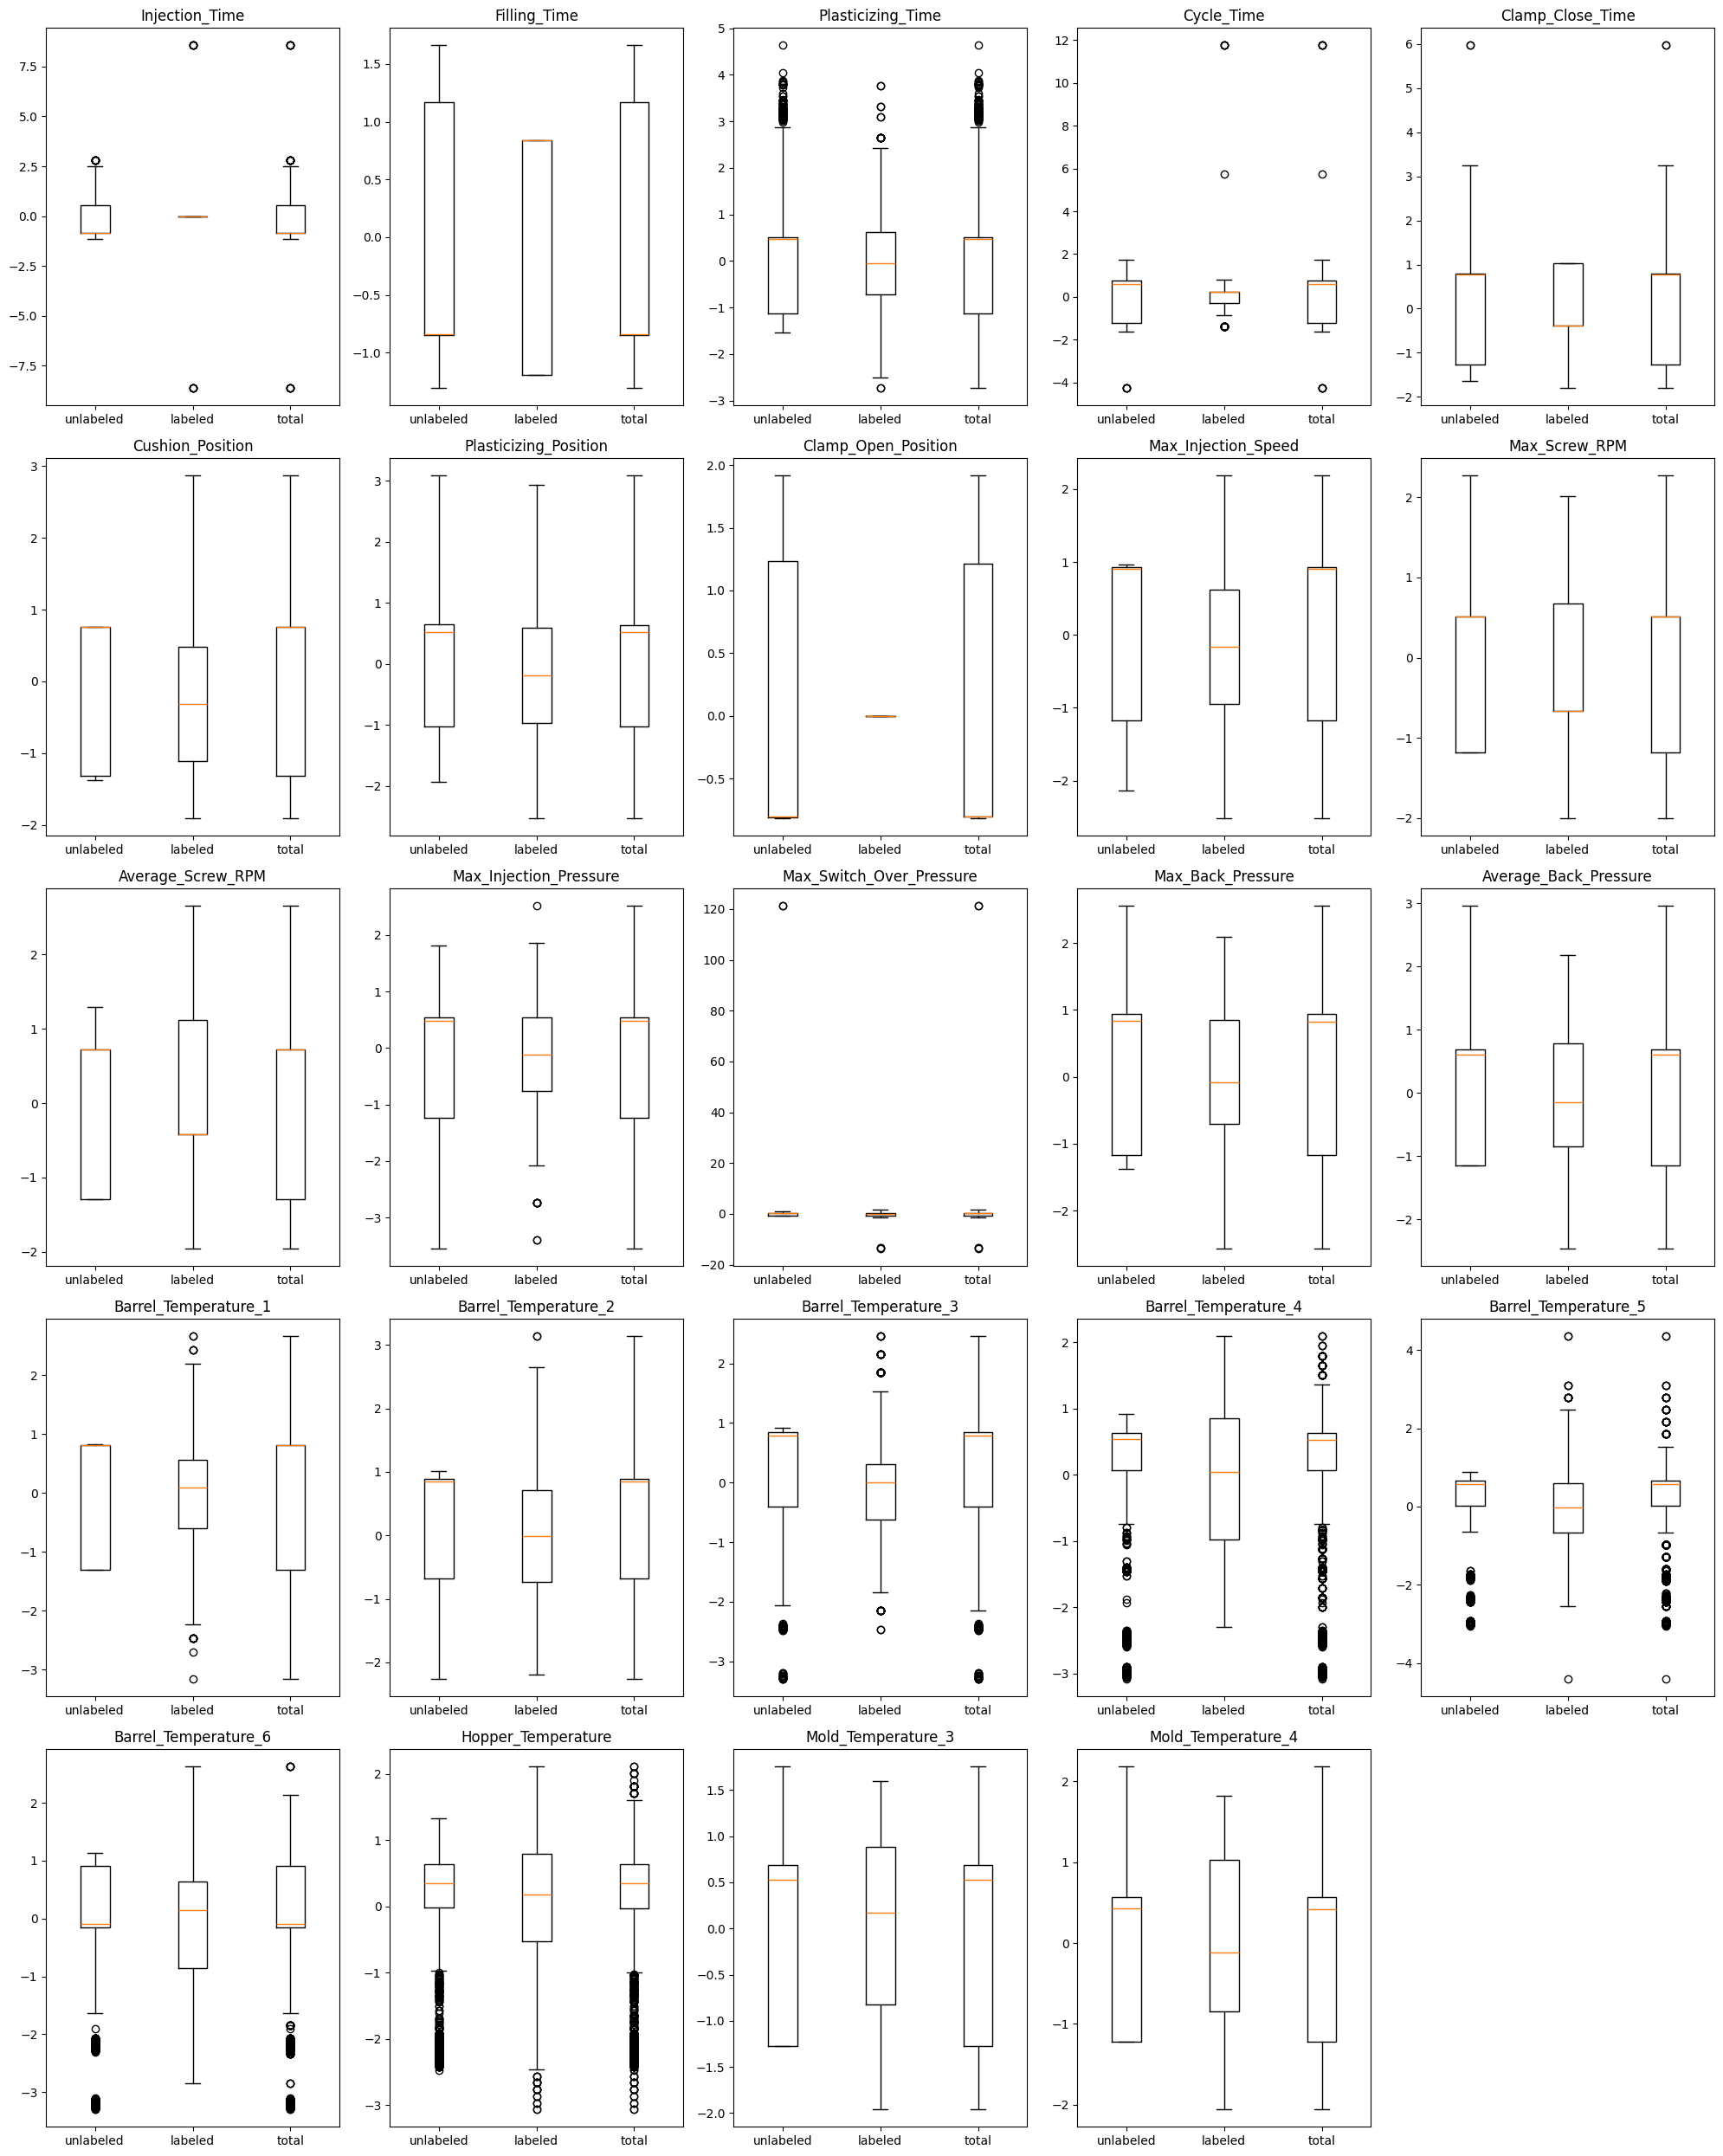

In [71]:
# draw boxplot
total_rg3 = pd.concat([unlabeled_rg3,X_with_label_rg3])
plt.figure(figsize=(20, 25))

for index, value in enumerate(unlabeled_rg3.columns):
    ax = plt.subplot(5, 5, index + 1)
    ax.boxplot(x=[unlabeled_rg3[value],X_with_label_rg3[value],total_rg3[value]], tick_labels=['unlabeled','labeled','total'])
    ax.set_title(value)

plt.tight_layout()

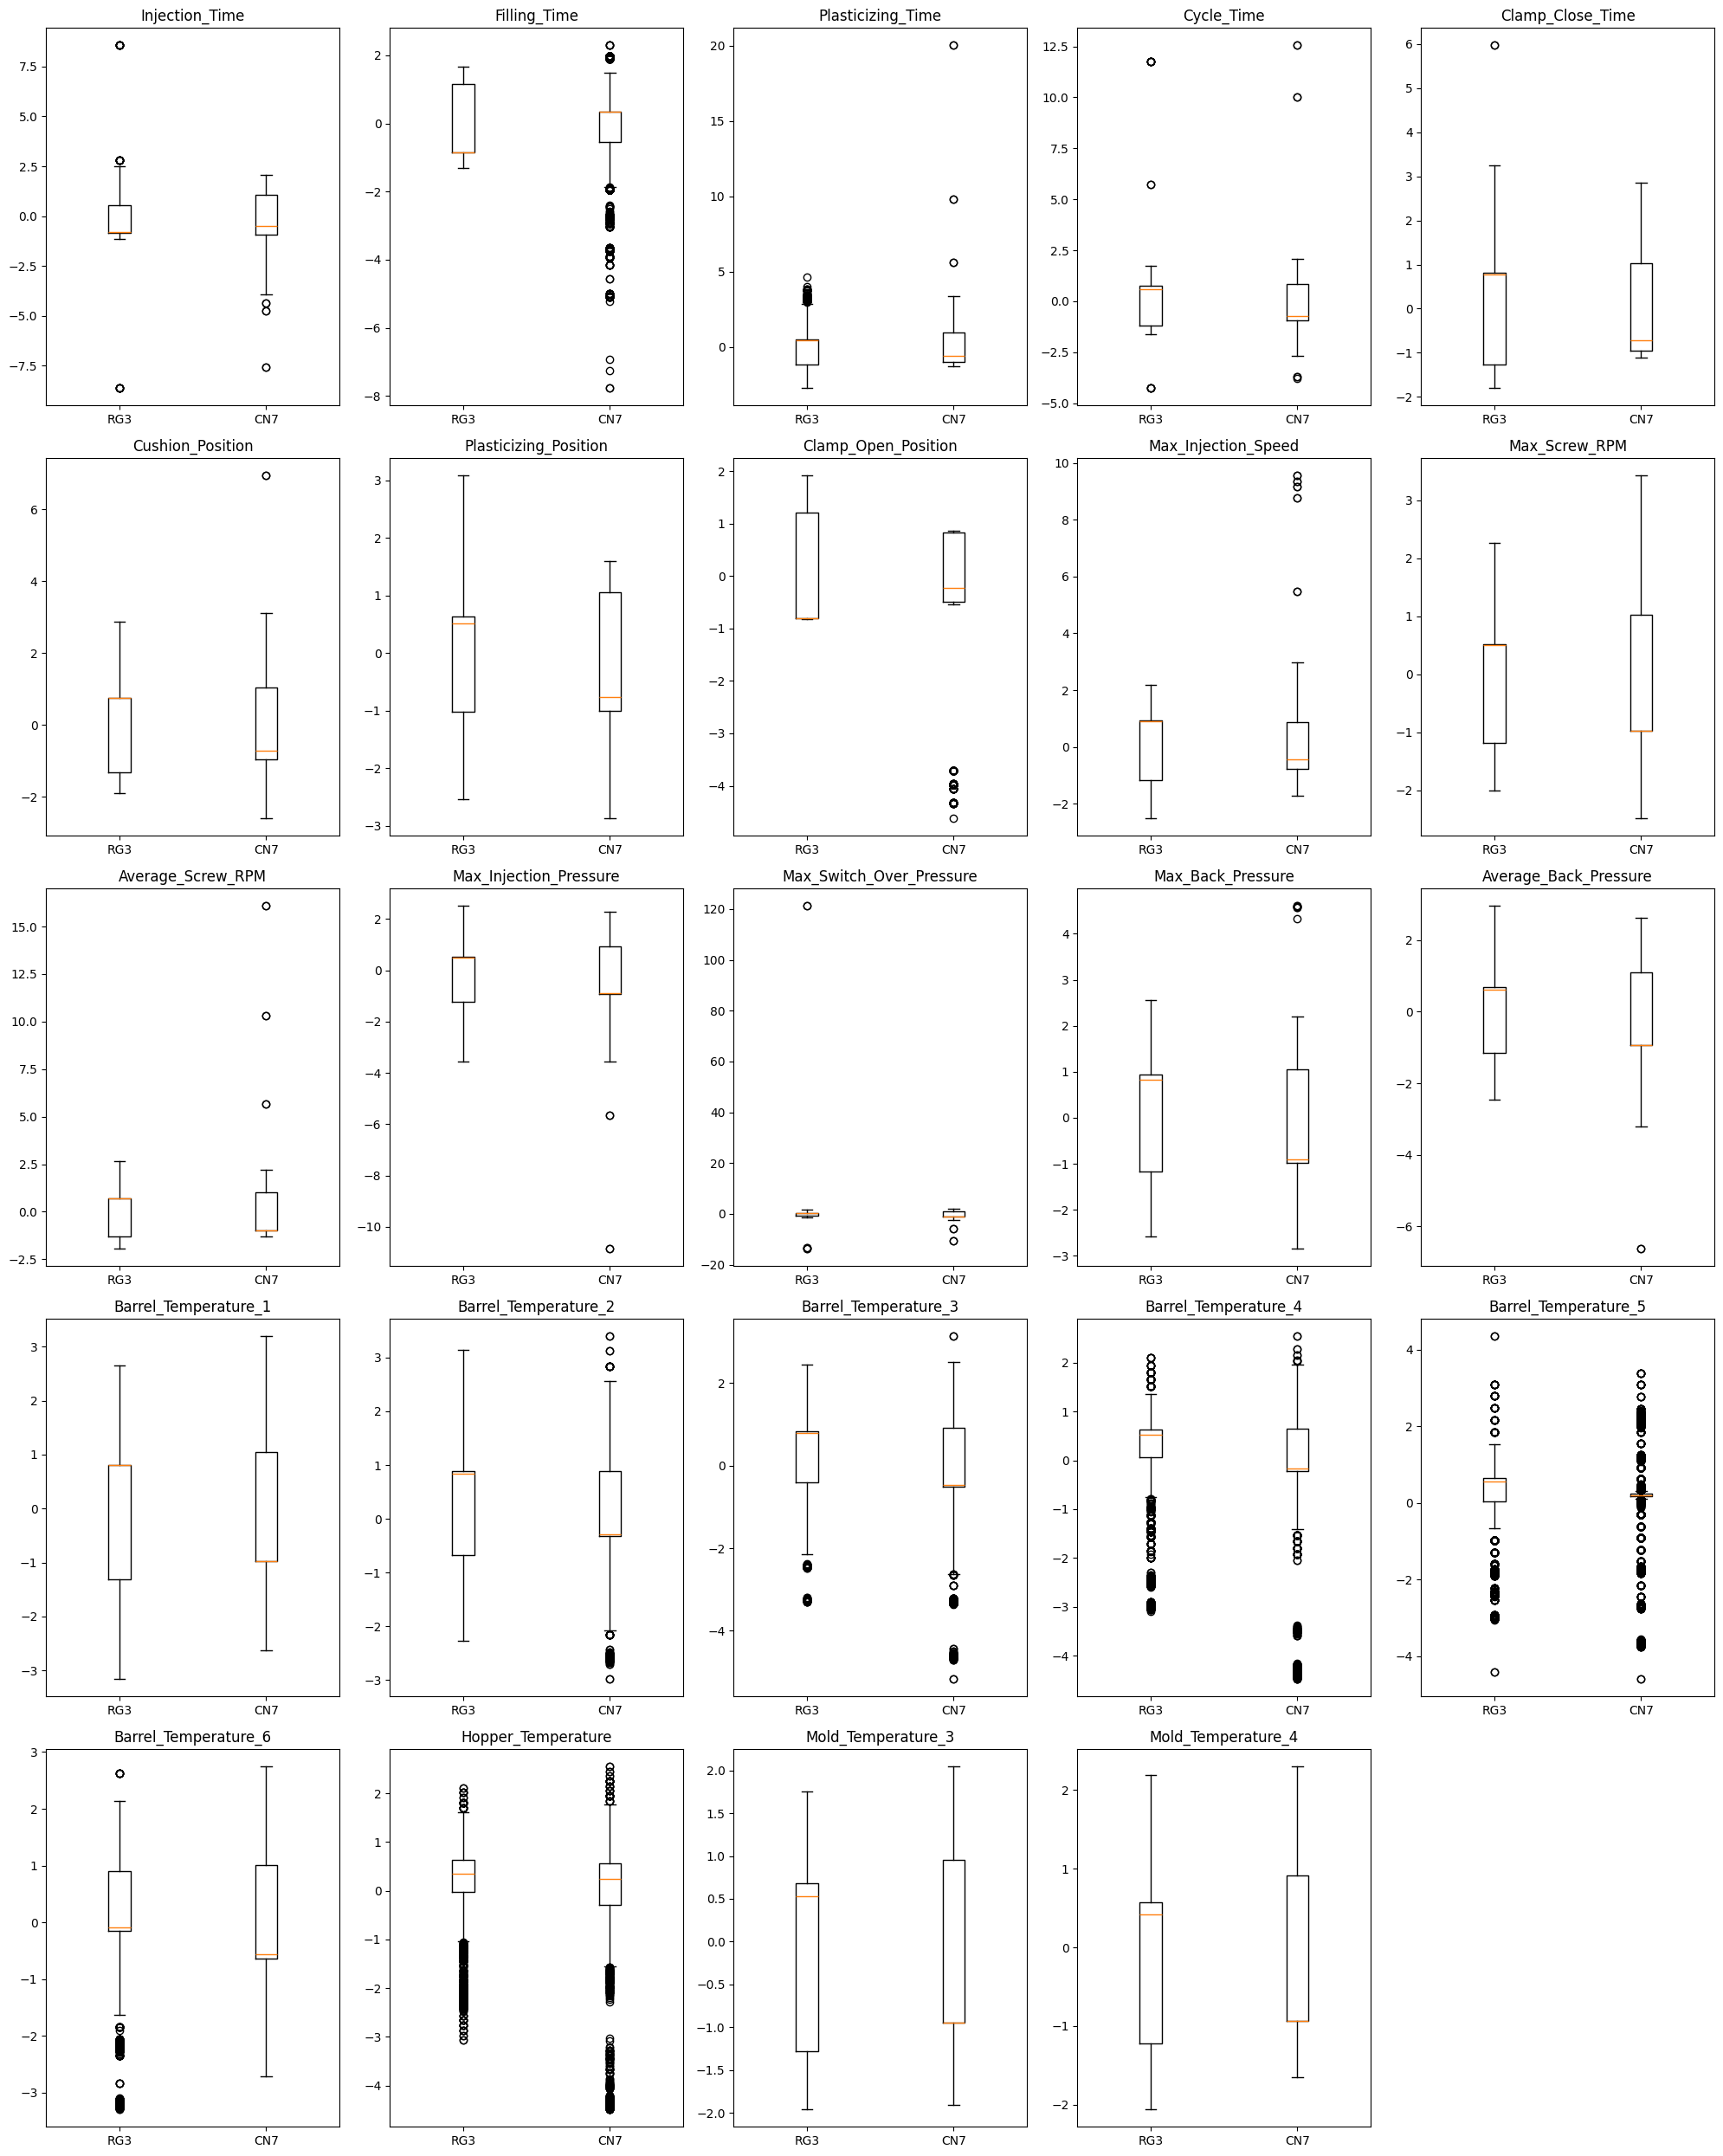

In [ ]:
# visualize the distribution of every feature for each products
# used data : total_cn7, total_rg3 (unlabeled+labeled)
plt.figure(figsize=(20, 25))

for index, value in enumerate(total_rg3.columns):
    if value == 'PassOrFail':
        continue
    ax = plt.subplot(5, 5, index + 1)
    ax.boxplot(x=[total_rg3[value],total_cn7[value]], tick_labels=['RG3','CN7'])
    ax.set_title(value)

plt.tight_layout()

CN7, RG3에 따라 피처별 데이터 분포가 다르므로 제품별 전처리를 다르게 할 것

In [82]:
tr_from_labeled_cn7 = pd.concat([X_with_label_cn7, y_with_label_cn7], axis=1)
tr_from_labeled_rg3 = pd.concat([X_with_label_rg3, y_with_label_rg3], axis=1)

display(tr_from_labeled_cn7)
display(tr_from_labeled_rg3)

,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,...,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,PassOrFail
51,0.475456,0.282513,-0.527100,0.361047,0.978580,-0.711164,1.471608,0.0,-0.373631,0.049553,...,-1.514083,2.010468,-1.306874,-0.006117,2.162308,-0.897571,-0.974733,1.023094,1.287574,0
498,-0.327014,-0.120461,-0.281692,-0.655762,0.978580,1.202502,-0.702654,0.0,0.015756,-1.641030,...,-1.514083,0.067358,0.279582,-1.664171,0.315892,-0.442241,-0.370434,-1.480593,-1.250466,0
1175,-1.129445,-1.329345,0.307302,-1.164166,-0.902466,-0.711164,-0.581880,0.0,0.794530,0.049553,...,0.056153,1.455270,-0.037728,-0.261181,0.008133,0.923887,1.543186,0.236222,-0.056094,0
1044,0.074221,-0.120461,0.356386,-0.655762,-0.902466,-0.711164,-0.702654,0.0,0.015756,0.894853,...,-0.841164,-1.042954,-0.989563,-0.388733,0.623605,0.468557,1.946055,0.236222,-0.056094,0
833,0.074221,-0.120461,0.209135,0.361047,-0.902466,-0.711164,-0.581880,0.0,0.210445,0.049553,...,-0.616835,1.177755,-0.355039,-0.388733,0.008133,-2.263700,0.435303,-0.192982,-0.354687,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
504,-0.327014,-0.120461,-0.085357,0.361047,0.978580,1.202502,-0.581880,0.0,0.210445,0.049553,...,2.074980,0.622557,1.866039,-0.261181,0.008133,-0.897571,-0.370434,-1.409059,-1.250466,0
399,0.475456,0.282513,-0.134441,0.361047,0.978580,1.202502,-0.642290,0.0,0.015756,-0.795730,...,2.074980,-1.320553,-1.941496,-0.643836,-0.607339,-0.897571,-0.571865,-1.909796,-1.598823,0
1028,0.074221,0.282513,0.160051,-0.655762,-0.902466,-0.711164,-0.702654,0.0,-0.178934,2.585452,...,-1.065425,-1.598068,-0.037728,0.886706,0.623605,0.013158,1.241040,0.164688,-0.056094,0
767,-0.728249,-0.926390,0.160051,0.361047,0.978580,1.202502,-0.642290,0.0,0.599832,0.049553,...,-0.168176,-0.487756,0.279582,0.376538,-0.299626,-0.897571,-0.269711,-0.407585,-0.503983,0


,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,...,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,PassOrFail
1240,-0.029099,-1.192531,2.651155,-0.572765,1.033078,2.075089,-2.537409,0.0,2.187583,0.677109,...,0.562844,1.927290,-0.002081,-0.683487,-1.284641,1.137306,0.488266,-1.820935,-1.818827,0
1581,-0.029099,0.838552,-0.042538,-0.298708,1.033078,-0.317055,-0.974521,0.0,-0.167384,-0.665752,...,1.495203,1.442567,1.227136,0.194005,0.282727,-0.354184,-0.121809,0.031342,-0.119337,0
1590,-0.029099,-1.192531,-0.491498,0.249511,1.033078,1.277707,-0.974521,0.0,1.402554,-2.008588,...,1.028988,-0.253813,0.305246,0.925242,0.596220,-0.354184,-0.325165,0.031342,-0.119337,0
1370,-0.029099,-1.192531,1.753258,0.249511,-0.386790,0.480326,-0.192928,0.0,0.617645,-0.665752,...,0.795880,-0.980897,-0.309409,-1.707191,2.790479,0.143005,0.081547,-1.108521,-0.969082,0
1321,-0.029099,0.838552,0.181942,0.249511,-0.386790,-0.317055,0.588367,0.0,-0.167384,-0.665752,...,0.562844,0.957919,0.305246,0.925242,-0.344258,1.137306,0.996663,-0.966038,-0.847689,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2179,8.569634,0.838552,-0.042538,-0.846822,-1.806725,2.075089,1.369662,0.0,-1.737322,-0.665752,...,1.728310,0.230835,-0.002081,0.486518,-0.344258,-0.354184,-1.036925,1.028719,1.094583,0
1241,-0.029099,-1.192531,2.202217,-0.024546,1.033078,1.277707,-1.755816,0.0,1.402554,-0.665752,...,-1.068838,-0.011452,0.305246,-1.853447,1.536603,-0.354184,-0.121809,-1.678451,-1.697434,0
1531,-0.029099,0.838552,-1.613854,-0.298708,1.033078,-0.317055,-0.974521,0.0,-0.167384,-2.008588,...,1.262095,-0.496175,1.227136,1.656478,-0.030765,0.640193,0.691629,-0.253624,-0.483514,0
1404,-0.029099,-1.192531,0.630880,0.249511,-0.386790,1.277707,0.588367,0.0,1.402554,-0.665752,...,-0.369586,0.715557,-0.002081,-0.829743,-0.030765,-0.354184,0.183232,-0.823555,-0.969082,0


In [83]:
# correlation between features and target variable
corr_cn7 = pd.DataFrame(tr_from_labeled_cn7.corr()['PassOrFail']).reset_index(names='features')
corr_rg3 = pd.DataFrame(tr_from_labeled_rg3.corr()['PassOrFail']).reset_index(names='features')
corr_coef = pd.merge(left=corr_cn7, right=corr_rg3, how='left', on='features')
corr_coef.rename(columns={'PassOrFail_x':'corr_cn7','PassOrFail_y':'corr_rg3'}, inplace=True)
corr_coef.sort_values(by='corr_cn7', ascending=False)

,features,corr_cn7,corr_rg3
24,PassOrFail,1.000000,1.000000e+00
8,Max_Injection_Speed,0.312297,-2.433235e-02
6,Plasticizing_Position,0.173905,-2.594767e-02
23,Mold_Temperature_4,0.159650,-2.853385e-02
22,Mold_Temperature_3,0.142553,-2.877037e-02
4,Clamp_Close_Time,0.132393,4.610150e-02
12,Max_Switch_Over_Pressure,0.085764,2.369791e-02
3,Cycle_Time,0.041212,3.426154e-03
20,Barrel_Temperature_6,0.025143,6.853113e-03
18,Barrel_Temperature_4,0.018168,-1.061945e-02


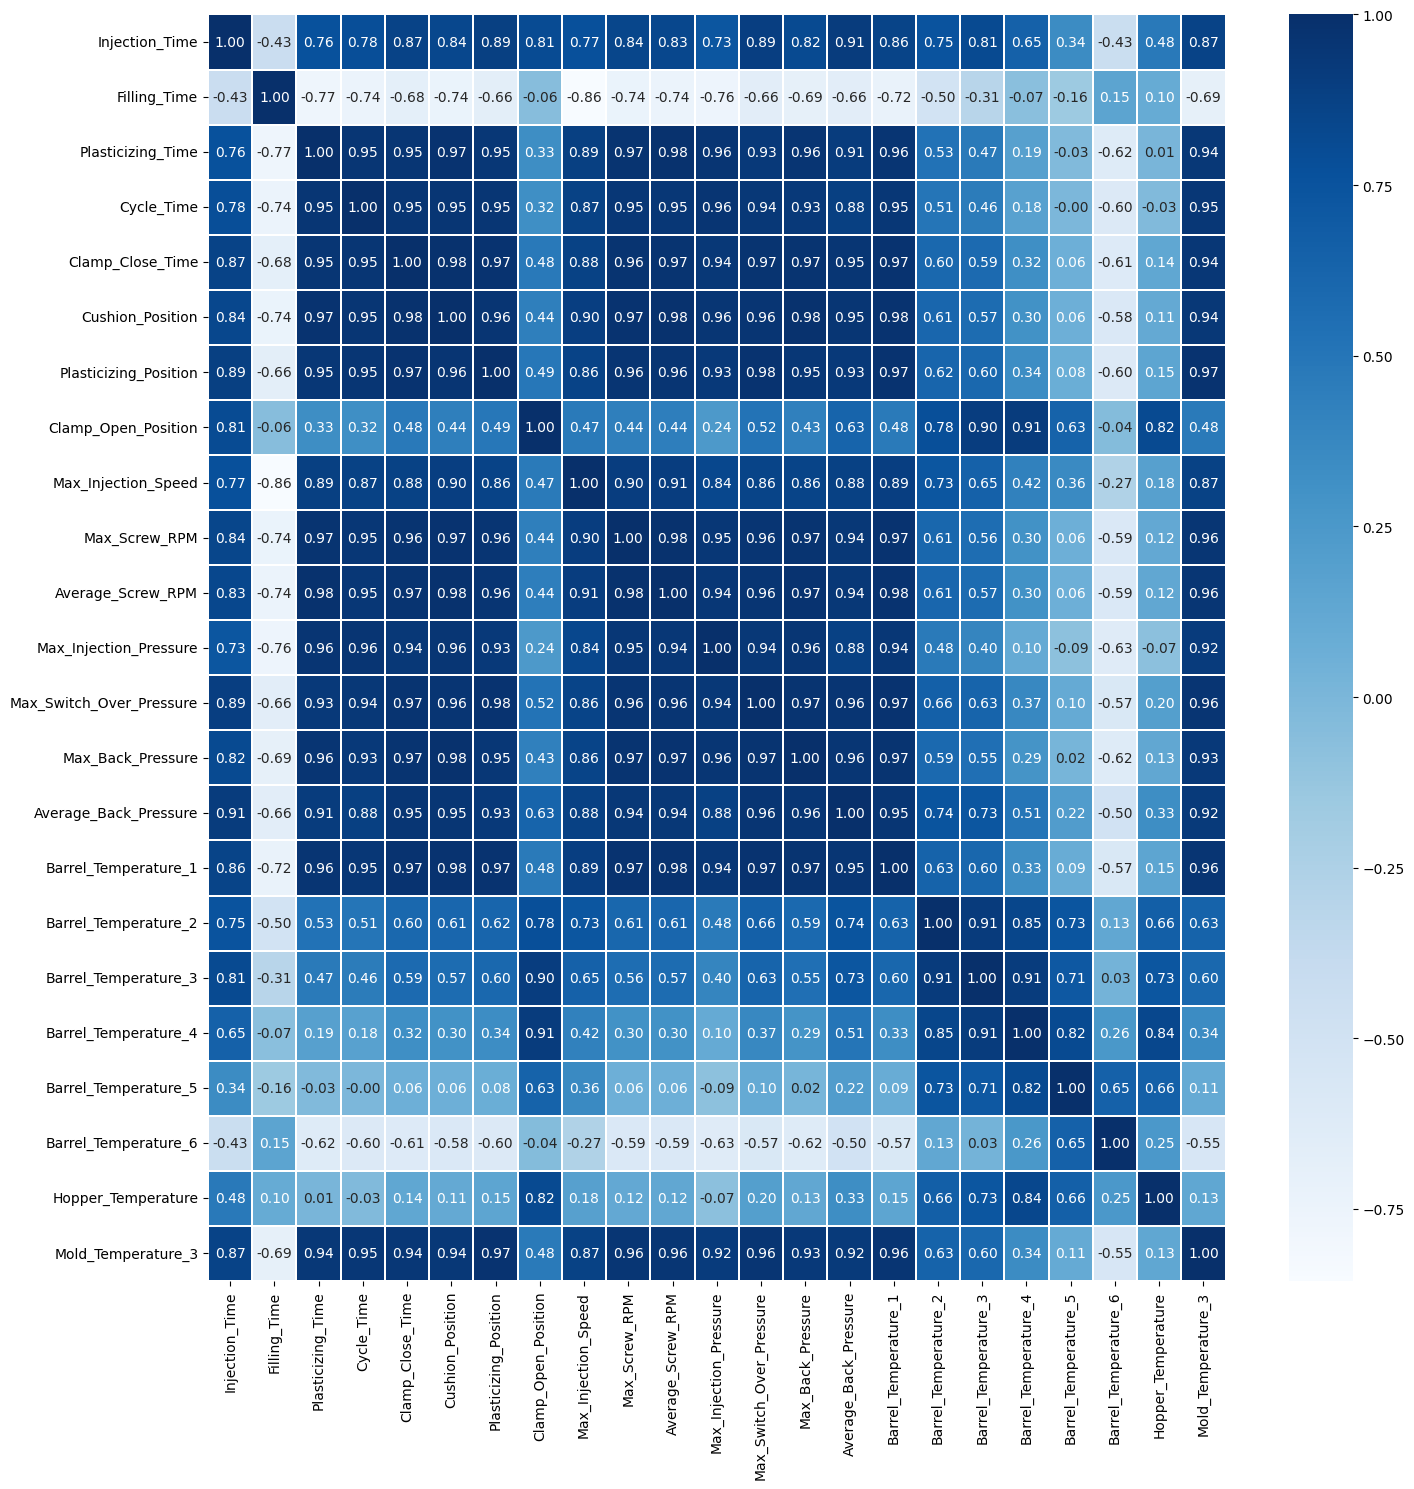

In [84]:
# correlation heatmap
# total_cn7, without target variable
plt.subplots(figsize=(15,15))
sns.heatmap(data=total_cn7.iloc[:,:-1].corr(), annot=True, fmt='.2f', linewidths=0.1, cmap='Blues')
plt.tight_layout()

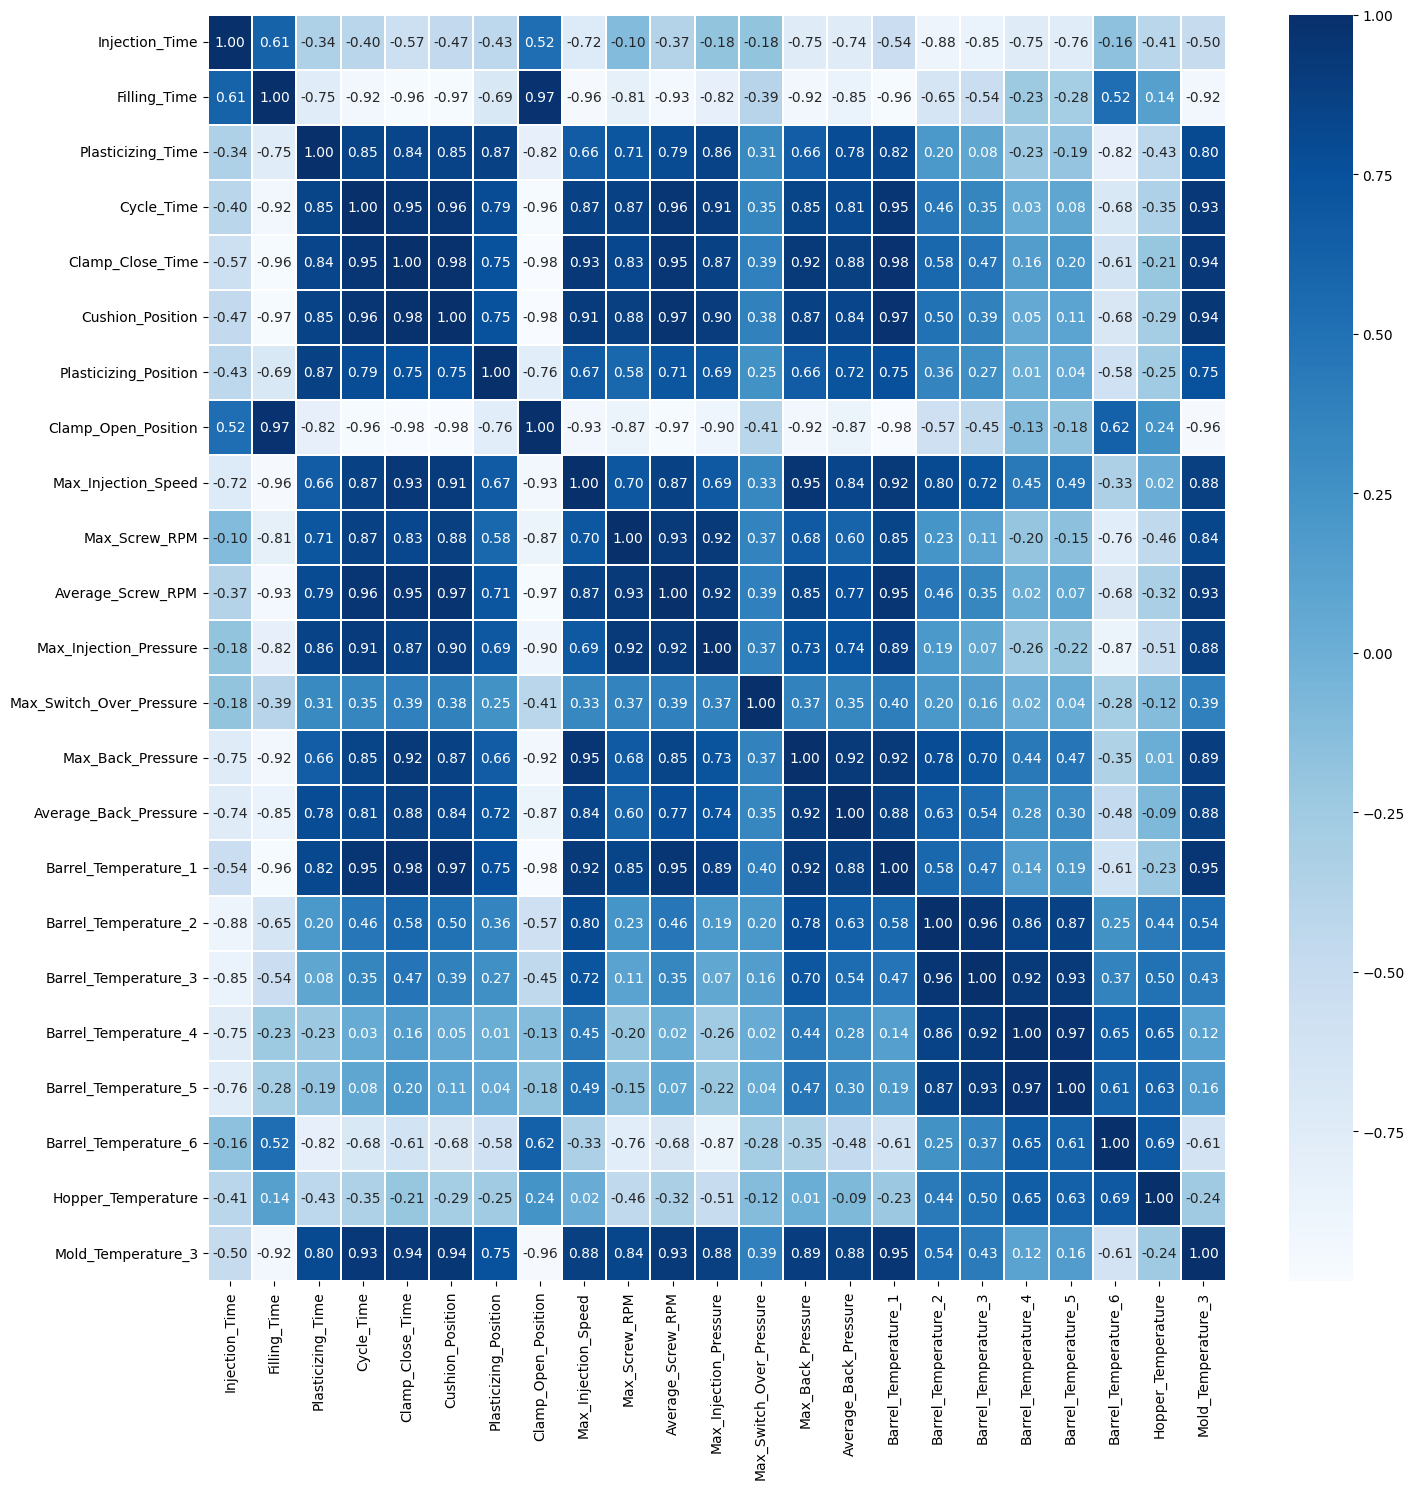

In [85]:
# correlation heatmap
# total_rg3, without target variable
plt.subplots(figsize=(15,15))
sns.heatmap(data=total_rg3.iloc[:,:-1].corr(), annot=True, fmt='.2f', linewidths=0.1, cmap='Blues')
plt.tight_layout()